# Battery Optimization with Price effects Version 1.5.1
Modified the author's code to be able to read in AESO prices. Here I use prices for the year 2023.
NOTE: Still haven't added in Wind and Solar yet.

source:
\
https://medium.com/@yeap0022/basic-build-optimization-model-to-schedule-batterys-operation-in-power-grid-systems-51a8c04b3a0e

### Loading in packages

In [1]:
# Let's load in the necessary packages

import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt

from ortools.linear_solver import pywraplp
import numpy as np

In [5]:
# Loading in price data

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)

# IMPORTANT: Adding this line that filters out for the "SMP"
workbook = workbook[workbook['price']==workbook['mkt_price']] # NOTE: this has to be changed: this will break when there's a tie EXAMPLE: day when price is 0

marketDF = workbook[["datetime", "price", "ail","solar_tot","wind_tot"]] # Gets the columns that we need

marketDF.columns = ["time","market_price_1","load","wind","solar"] # Using author's naming for the columns
marketDF = marketDF[~pd.isnull(marketDF["time"])].fillna(0) # Not sure what this does yet, my guess is fill in empty cells

# From author's code: Will manipulate the time and date variable
market1DF = marketDF.copy()

# market1DF.sort_values(by = ["time"], inplace = True) # THIS ACTUALLY DESTROYS THE SORTING FOR SOME REASON. Silencing it for now.

market1DF["time"] = market1DF.apply(lambda x: datetime.datetime.strptime(x["time"],"%Y-%m-%d %H:%M"), axis = 1)


# Below creates another column, "time_string", that has a different format. .apply() and lambda applies a function to the cells.
# timedelta() computes for the differences in times usually or for datetime manipulation. .strftime() formats the time variable
market1DF["time_string"] = market1DF.apply(lambda x: (x["time"]+datetime.timedelta(seconds = 0.002)).strftime("%d/%m/%Y %H:%M"),axis = 1)
market1DF.set_index("time_string", inplace = True) # Sets the new column as the time index of this time series dataset.
marketDF = market1DF

del market1DF # Deleting the duplicate dataframe to save on memory and processing

# Just remove the "#" if we want to take a look at the price data.
# marketDF

KeyError: "['datetime', 'solar_tot', 'wind_tot'] not in index"

In [3]:
# Here I'll try to put the market price data into a dictionary, just as the author did.
# This is in hopes of speeding up processing times; UPDATE: It does save some processing time, around 0.5 seconds.

market_dict = marketDF.to_dict()
# market_dict

In [4]:
# This is how information from the dictionary should be referenced, using the time index
# market_dict["market_price_1"]["01/01/2023 18:00"]

In [5]:
# Like what the author did, it'll be useful to create a "time array" that will help reference each value
# NOTE: This array starts at 0
time_list = marketDF["market_price_1"].keys()
time_list[0]

'10/04/2024 01:00'

In [6]:
# And now we use that to reference the dictionary
market_dict["market_price_1"][time_list[8]]

31.4

This is mainly where the code was changed. I took away the use of dictionaries (for now) in order to avoid the problem of missing data points.

In [7]:
# From Author's code:
# Creating a time interval; our time interval here is one hour
timeInterval = marketDF.iloc[1]["time"] - marketDF.iloc[0]["time"]
timeInterval

Timedelta('0 days 01:00:00')

#### Static Data
(Electricity Grid data, and Battery parameters)

For the static data, I'll veer a bit more from the original author and create dataframes directly instead of having to read a file.

##### Grid Data

In [8]:
#### GRID DATA ####
grid_dict = {
    'max_buy_power':99999,
    'max_sell_power':99999,
    'max_import_power':99999,
    'max_export_power':99999
}

gridDF = pd.DataFrame.from_dict(grid_dict, orient = 'index').transpose() # Turns the dictionary above into a dataframe
del grid_dict
gridDF

,max_buy_power,max_sell_power,max_import_power,max_export_power
0,99999,99999,99999,99999


##### Battery Data

If we want to make changes to the parameters of our battery, we do so in this cell.
Note: charge/discharge and capacity are in MW. SOC means state of charge, and this is in percentage.

In [9]:
#### BATTERY DATA ####

# Creating the parameters of the battery here, and if we want to make changes to our battery this is where we can adjust it.
batt_dict = {
    'max_charge_rate':300,
    'max_discharge_rate':300,
    'capacity':1200,
    'charge_eff':0.1,
    'discharge_eff':0.1,
    'min_soc':0.1,
    'max_soc':0.95,
    'initial_soc':0.5
}

battDF = pd.DataFrame.from_dict(batt_dict, orient = 'index').transpose()
del batt_dict
battDF

,max_charge_rate,max_discharge_rate,capacity,charge_eff,discharge_eff,min_soc,max_soc,initial_soc
0,300.0,300.0,1200.0,0.1,0.1,0.1,0.95,0.5


### Declare Mixed Integer Programming Solver
(NOTE: depending on the computer, this may need to be changed.)

In [10]:
# Declaring the solver to be used

# Create the MIP solver
solver = pywraplp.Solver.CreateSolver("scip")

inf = solver.infinity()

### Variables Setup

In [11]:
# Defining the Variables in author's battery

tIndex = marketDF.shape[0] # Getting the number of observations

time_s = timeit.default_timer()

# Add timeseries variables
vGrid = [solver.NumVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]

vBattPower = [solver.NumVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]
vCharge = [solver.NumVar(lb = -inf, ub = 0, name = "") for _ in range(tIndex)] # vCharge has these bounds because charging is an expense (-)
vDischarge = [solver.NumVar(lb = 0, ub = inf, name = "") for _ in range(tIndex)] # vDischarge is positive, selling power (+)
vChargeStatus = [solver.BoolVar(name="") for _ in range(tIndex)]
vSOC = [solver.NumVar(lb = 0, ub = 1, name = "") for _ in range(tIndex)]


### Constraints Setup

In [12]:
# Defining first the time interval dt
# For now, the time interval is equal to 1 since we're going hourly.
dt = int(round(timeInterval.total_seconds())) / (60 * 60) # 60 * 60 because 3600 seconds in an hour.
dt

1.0

In [13]:
# Setting up the constraints. The mathematical expressions can be found on the author's website.

for i in range(tIndex):

    # Grid Constraints
    solver.Add(vGrid[i] == market_dict["load"][time_list[i]] - market_dict["solar"][time_list[i]] -market_dict["wind"][time_list[i]] - vBattPower[i]) # Eq. (1)
    solver.Add(vGrid[i] <= gridDF["max_buy_power"][0]) # Eq. (2)
    solver.Add(vGrid[i] >= -gridDF["max_sell_power"][0]) # Eq. (2)
    # Eq. (3) below, first half of it
    solver.Add(market_dict["load"][time_list[i]] - market_dict["solar"][time_list[i]] - market_dict["wind"][time_list[i]] + vDischarge[i] + vCharge[i] <= gridDF["max_import_power"][0])
    # Eq. (3) second half:
    solver.Add(market_dict["load"][time_list[i]] - market_dict["solar"][time_list[i]] - market_dict["wind"][time_list[i]] + vDischarge[i] + vCharge[i] >= -gridDF["max_export_power"][0])

    # Battery Constraints
    solver.Add(vBattPower[i] == vCharge[i] + vDischarge[i]) # Eq. (4)
    solver.Add(vCharge[i] >= -battDF["max_charge_rate"][0] * vChargeStatus[i]) # Eq. (5a), recall that vChargeStatus is a Boolean variable
    solver.Add(vDischarge[i] <= battDF["max_discharge_rate"][0] * (1-vChargeStatus[i])) # Eq. (5b)

    if i == 0: # Everything in this equation is Eq. (6), it's in an if-else because of the initial case or state of the SOC (state of charge)
        solver.Add(vSOC[i] == battDF["initial_soc"][0] - dt / battDF["capacity"][0] * (vCharge[i] * (1-battDF["charge_eff"][0]) + vDischarge[i] / (1-battDF["discharge_eff"][0])))
    else:
        solver.Add(vSOC[i] == vSOC[i-1] - dt / battDF["capacity"][0] * (vCharge[i] * (1-battDF["charge_eff"][0]) + vDischarge[i] / (1-battDF["discharge_eff"][0])))


### Objective Function

Made the slight change of multiplying the prices to the battery charges/discharges. Has the same results.

In [14]:
# Add objective
# Changed the objective to sum up the battery energy times the price, instead of power in the grid.
obj = 0
obj += -sum([vBattPower[i] * marketDF["market_price_1"].iloc[i] * dt for i in range(tIndex)])
solver.Minimize(obj)

### Solving and Printing Results

In [15]:
# These codes run the model using the solver and get the solutions
status = solver.Solve()

time_e = timeit.default_timer()
runTime = round(time_e - time_s, 4)

#### Constructing table of results

In [16]:
# Constructing the results table:

results_table = pd.DataFrame() # Make an empty one first

# And then we add to the the dataframe above, building it.
results_table["datetime"] = marketDF["time"].to_numpy() # Getting the time variable. Calling it "datetime" for the next stage.
# These two lines just make the index column for time.
results_table["time_string"] = results_table["datetime"]
results_table.set_index("time_string", inplace = True)

results_table["market_price_dolmw"] = marketDF["market_price_1"].to_numpy()
results_table["end_soc"] = list(vSOC[i].solution_value() for i in range(tIndex)) # To indicate that the state of charge is AFTER THE FACT.
results_table["batt_power"] = list(vBattPower[i].solution_value() for i in range(tIndex))

# When the whole table is in, then this should be run
results_table["index"] = range(len(results_table))

# Adding more detail:
results_table['transaction'] = results_table['batt_power']*results_table['market_price_dolmw']
results_table['start_soc'] = results_table['end_soc'].shift(1)
results_table['start_soc'] = np.where(results_table['start_soc'].isnull() ,battDF.iloc[0]['initial_soc'],results_table['start_soc'])
results_table = results_table[['datetime','market_price_dolmw','start_soc','end_soc','batt_power','transaction','index']]

results_table.to_csv("batt_opt.csv")
results_table


,datetime,market_price_dolmw,start_soc,end_soc,batt_power,transaction,index
time_string,,,,,,,
2024-04-10 01:00:00,2024-04-10 01:00:00,68.48,0.500000,0.222222,300.000000,20544.000000,0
2024-04-10 02:00:00,2024-04-10 02:00:00,43.83,0.222222,0.000000,240.000000,10519.200000,1
2024-04-10 03:00:00,2024-04-10 03:00:00,31.36,0.000000,0.225000,-300.000000,-9408.000000,2
2024-04-10 04:00:00,2024-04-10 04:00:00,30.96,0.225000,0.450000,-300.000000,-9288.000000,3
2024-04-10 05:00:00,2024-04-10 05:00:00,31.71,0.450000,0.555556,-140.740741,-4462.888889,4
2024-04-10 06:00:00,2024-04-10 06:00:00,39.92,0.555556,0.277778,300.000000,11976.000000,5
2024-04-10 07:00:00,2024-04-10 07:00:00,45.69,0.277778,0.000000,300.000000,13707.000000,6
2024-04-10 08:00:00,2024-04-10 08:00:00,32.35,0.000000,0.000000,0.000000,0.000000,7
2024-04-10 09:00:00,2024-04-10 09:00:00,31.40,0.000000,0.000000,0.000000,0.000000,8


In [17]:
# Battery earnings for the year:
-solver.Objective().Value()

520756.9777777759

In [18]:
# This should also be the same value
results_table['transaction'].sum()

# NOTE: Differences most likely due to rounding.

520756.97777777776

# Battery Effects on Prices

In [19]:
# Getting the merit order first again

file_name = os.fsdecode('marco_data.csv')
merit_data = pd.read_csv(file_name)

# Fixing the "datetime" variable for the data
# Got this line of code from the author of the Battery Optimizer
merit_data['datetime'] = merit_data.apply(lambda x: datetime.datetime.strptime(x["datetime"],"%Y-%m-%d %H:%M"), axis = 1)


In [20]:
# Let's build this from a new perspective

batt_hr = 0
batt_activity = results_table

# Declaring an empty dataframe that will collect all of the new prices

new_p_df = pd.DataFrame()
new_p_df['datetime'] = results_table['datetime']
new_p_df['new_p'] = results_table['market_price_dolmw']


#### Main Price Adjusting Loop

In [21]:
#################################
##### PRICE ADJUSTING LOOP #####
#################################

for batt_hr in range(len(batt_activity)):
    #### FILTERING ###########------------------------------------------------------------------------------------------------
    # Filter out the specific hour, and then reset the index for the purposes of better processing.
    temp_hr = merit_data[batt_activity.iloc[batt_hr]['datetime']==merit_data['datetime']]
        # Codes to reset the index.
    # Once again we sort our data and this puts our battery on top.
    temp_hr = temp_hr.sort_values(by='block') # Sorting by block, and our battery was given the 0 block number.
    temp_hr = temp_hr.reset_index()
    temp_hr = temp_hr.drop('index',axis=1) # Takes out the "index" column; comes out when using the .reset_index() method
    #--------------------------------------------------------------------------------------------------------------------------
    #### ADDING BATTERY INTO MERIT ###########---------------------------------------------------------------------------------
    # Easier to add the battery in a dictionary first
    batt_add_dict = {
        "date":temp_hr["date"][len(temp_hr)-1], # This line and the one below just gets the hour and the date of this certain hour.
        'he': temp_hr["he"][len(temp_hr)-1],
        "asset_id":"MCP_1", # Name of our battery so far.
        # Size should show what the asset CAN OFFER during the hour.
                # NOTE: the state of charge variable is AFTER THE FACT; shows the state of charge after the battery made a move.
        # 'size': battDF.iloc[0]['initial_soc'] * battDF.iloc[0]['capacity'], # Needs to be changed! "size" is how much the asset CAN OFFER. Not the capacity.
        # This would be different from the previous charging we did, since the state of charge is not the initial one anymore.
                # NOTE: It should also technically not matter right now because our battery is buying from the market, and not offering.
        'size': min(batt_activity.iloc[batt_hr]['start_soc']*battDF.iloc[0]['capacity']*(1-battDF.iloc[0]['discharge_eff']),
                    battDF.iloc[0]['max_discharge_rate']),
        
        "price": 0, # Possibly changed if we change assumptions (i.e. making the battery strategic in bidding)
        "dispatched":"Y",
        'flexible':'Y',
        'block':0,
        'merit':0, # Will be changed
        'mkt_price':temp_hr['mkt_price'][len(temp_hr)-1], # Will possibly be changed
        'dispatched_mw' : batt_activity.iloc[batt_hr]['batt_power'], # Get's the power sold by the battery
        'ail':temp_hr['ail'][len(temp_hr)-1],
        'dispatched_merit':0, # Will be changed
        "hour":temp_hr['hour'][len(temp_hr)-1],
        'datetime': temp_hr['datetime'][len(temp_hr)-1],
        'solar_tot': temp_hr['solar_tot'][len(temp_hr)-1],
        'wind_tot': temp_hr['wind_tot'][len(temp_hr)-1]
    }
    
    # Now we're converting our battery dictionary into a dataframe that will be concatenated to the hour.
    batt_add = pd.DataFrame.from_dict(batt_add_dict,orient = 'index').transpose()
    # Concatenates the battery to the end of the temp_hr dataframe
    temp_hr = pd.concat([temp_hr,batt_add], ignore_index=True)
    temp_hr = temp_hr.sort_values(by='block') # Sorting according to block number, places battery on the top
    del batt_add, batt_add_dict
    #--------------------------------------------------------------------------------------------------------------------------
    #### PRICE ADJUSTING PART ############-------------------------------------------------------------------------------------
    
    #### START OF PRICE ADJUSTING ###########----------------------------------------------------------------------------------
    # Adjusting the "dispatched_merit" column to compare with the AIL.
    temp_hr['dispatched_merit'] = temp_hr['dispatched_mw'].cumsum()
    # Indicate those that are over the AIL to stop dispatching
    temp_hr['dispatched'] = np.where(temp_hr['dispatched_merit'].round()>temp_hr['ail'].round(),'N', temp_hr['dispatched'])
    # Because of how computers read zeroes, we need to add this line below for the cases where the battery is not charging anything.
    temp_hr.at[temp_hr[temp_hr['price']==temp_hr['mkt_price']].index[0],'dispatched'] = np.where(abs(temp_hr['ail'].max()-temp_hr['dispatched_merit'].max())<1,
                                                                                                 'Y',
                                                                                                 temp_hr.iloc[temp_hr[temp_hr['price']==temp_hr['mkt_price']].index[0]]['dispatched'])
    # Now that those dispatching are correctly indicated, we need to reset the "dispatched mw" of those no longer currently generating
    temp_hr['dispatched_mw'] = np.where(temp_hr['dispatched']=='N',0,temp_hr['dispatched_mw'])
    
    # Let's get the energy that's still needed to satisfy demand.
    e_needed = temp_hr['ail'].max() - temp_hr[temp_hr['dispatched']=='Y']['dispatched_merit'].max() if temp_hr[temp_hr['block']==0].iloc[0]['dispatched_merit'] < temp_hr['ail'].max() else temp_hr['ail'].max()
    
    # Then let's get the index of the marginal bidder; we would like to loop through those next in line, starting with this bidder
    marg_block = temp_hr[temp_hr['dispatched']=='Y']['block'].max() if temp_hr[temp_hr['block']==0].iloc[0]['dispatched_merit'] < temp_hr['ail'].max() else 0
    
    #### PRICE ADJUSTING LOOP ###########--------------------------------------------------------------------------------------
    while e_needed > 0:
        # Check if the energy needed is greater than what the asset in question can provide
        if e_needed >= temp_hr.iloc[marg_block]['size']-temp_hr.iloc[marg_block]['dispatched_mw']:
            # If it is, asset then generates to full, indicated as dispatched, and energy needed is updated
            e_needed -= temp_hr.iloc[marg_block]['size']-temp_hr.iloc[marg_block]['dispatched_mw']
            temp_hr.at[temp_hr[temp_hr['block']==marg_block].index[0],'dispatched_mw'] += temp_hr.iloc[marg_block]['size']-temp_hr.iloc[marg_block]['dispatched_mw']
            marg_block += 1 # Marginal block is updated to move to the next asset
            
        # Next test: if the next asset is big enough for the energy needed, we need to see if it is flexible or not.
        elif temp_hr.iloc[marg_block]['flexible'] == 'Y':
            # If it is flexible, it will do mostly the same as above with a few differences.
            temp_hr.at[temp_hr[temp_hr['block']==marg_block].index[0],'dispatched_mw'] += e_needed
            e_needed = 0
            marg_block += 1 # Marginal block updated
        # Last test: if the next asset is not flexible, then the algorithm just skips over it.
        else:
            marg_block += 1
    ######################################--------------------------------------------------------------------------------------
    
    # Updating the dispatch column, market price, and dispatched merit.
    temp_hr['dispatched'] = np.where(temp_hr['dispatched_mw']>0,'Y','N')
    temp_hr['mkt_price'] = temp_hr[temp_hr['dispatched']=='Y']['price'].max()
    temp_hr['dispatched_merit'] = temp_hr['dispatched_mw'].cumsum()
    
    #--------------------------------------------------------------------------------------------------------------------------
    ##### COLLECTING THE NEW PRICES
    new_p_df['new_p'] = np.where(new_p_df['datetime']==temp_hr.iloc[0]['datetime'],temp_hr['mkt_price'].max(),new_p_df['new_p'])


In [22]:
# Looking at results in a table

res_tab = results_table
res_tab['new_p'] = new_p_df['new_p']
res_tab['price_change'] = res_tab['new_p'] - res_tab['market_price_dolmw']
res_tab = res_tab[['datetime','market_price_dolmw','new_p','price_change','start_soc','end_soc','batt_power','transaction','index']]
res_tab

,datetime,market_price_dolmw,new_p,price_change,start_soc,end_soc,batt_power,transaction,index
time_string,,,,,,,,,
2024-04-10 01:00:00,2024-04-10 01:00:00,68.48,40.89,-27.59,0.500000,0.222222,300.000000,20544.000000,0
2024-04-10 02:00:00,2024-04-10 02:00:00,43.83,32.27,-11.56,0.222222,0.000000,240.000000,10519.200000,1
2024-04-10 03:00:00,2024-04-10 03:00:00,31.36,43.83,12.47,0.000000,0.225000,-300.000000,-9408.000000,2
2024-04-10 04:00:00,2024-04-10 04:00:00,30.96,39.92,8.96,0.225000,0.450000,-300.000000,-9288.000000,3
2024-04-10 05:00:00,2024-04-10 05:00:00,31.71,37.03,5.32,0.450000,0.555556,-140.740741,-4462.888889,4
2024-04-10 06:00:00,2024-04-10 06:00:00,39.92,30.96,-8.96,0.555556,0.277778,300.000000,11976.000000,5
2024-04-10 07:00:00,2024-04-10 07:00:00,45.69,32.33,-13.36,0.277778,0.000000,300.000000,13707.000000,6
2024-04-10 08:00:00,2024-04-10 08:00:00,32.35,32.35,0.00,0.000000,0.000000,0.000000,0.000000,7
2024-04-10 09:00:00,2024-04-10 09:00:00,31.40,31.40,0.00,0.000000,0.000000,0.000000,0.000000,8


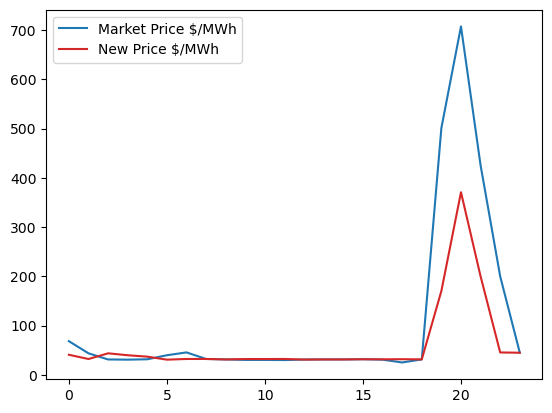

In [23]:
# I'll try to plot the two lines together for a better look
pltx = results_table["index"][:]
plty = new_p_df['new_p'][:]
plty2 = results_table["market_price_dolmw"][:]

# Plotting the lines
plt.plot(pltx, plty2, label = "Market Price $/MWh")
plt.plot(pltx, plty, label = "New Price $/MWh", color = 'tab:red')

plt.legend()
plt.show()